# **Rekomendasi Film**

...

## 1. Data Understanding 


### 1.1 Import Library

In [1]:
# Impor pustaka yang diperlukan 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk

### 1.2 Import & Dataset Understanding 

In [2]:
# Impor dataset 
movies = pd.read_csv('tmdb_5000_movies.csv')
movie = movies[['id', 'title', 'budget', 'genres', 'popularity', 'production_companies', 'revenue', 'vote_average', 'vote_count']]

In [3]:
# Tampilkan 5 baris teratas 
print('\n5 baris teratas:')
movie.head()


5 baris teratas:


,id,title,budget,genres,popularity,production_companies,revenue,vote_average,vote_count
0,19995,Avatar,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2787965087,7.2,11800
1,285,Pirates of the Caribbean: At World's End,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",961000000,6.9,4500
2,206647,Spectre,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",880674609,6.3,4466
3,49026,The Dark Knight Rises,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",1084939099,7.6,9106
4,49529,John Carter,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",284139100,6.1,2124


In [4]:
# Tampilkan informasi dataset
print('\nInformasi dataset:')
movie.info()


Informasi dataset:
<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    4803 non-null   int64  
 1   title                 4803 non-null   str    
 2   budget                4803 non-null   int64  
 3   genres                4803 non-null   str    
 4   popularity            4803 non-null   float64
 5   production_companies  4803 non-null   str    
 6   revenue               4803 non-null   int64  
 7   vote_average          4803 non-null   float64
 8   vote_count            4803 non-null   int64  
dtypes: float64(2), int64(4), str(3)
memory usage: 337.8 KB


In [5]:
# Hapus kolom id 
movie = movie.drop('id', axis=1)

In [6]:
# Tampilkan dimnesi dataset 
print('\nDimensi dataset:')
print('Jumlah baris:', movie.shape[0])
print('Jumlah kolom:', movie.shape[1])


Dimensi dataset:
Jumlah baris: 4803
Jumlah kolom: 8


In [7]:
# Simpan fitur sesuai tipe data 
num_cols = movie.select_dtypes(include=['int64', 'float64'])
cat_cols = movie.select_dtypes(include=['category', 'object'])

# Tampilkan fitur 
print('\nFitur numerik:', num_cols.columns.tolist())
print('Total fitur numerik:', num_cols.shape[1])
print('\nFitur kategori:', cat_cols.columns.tolist())
print('Total fitur kategori:', cat_cols.shape[1])


Fitur numerik: ['budget', 'popularity', 'revenue', 'vote_average', 'vote_count']
Total fitur numerik: 5

Fitur kategori: ['title', 'genres', 'production_companies']
Total fitur kategori: 3


/tmp/ipykernel_70953/2591630808.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = movie.select_dtypes(include=['category', 'object'])


In [8]:
# Tampilkan total nilai unik 
print('\nTotal nilai unik fitur numerik:')
num_cols.nunique()


Total nilai unik fitur numerik:


budget           436
popularity      4802
revenue         3297
vote_average      71
vote_count      1609
dtype: int64

In [9]:
# Tampilkan total nilai unik 
print('\nTotal nilai unik fitur kategori:')
cat_cols.nunique()


Total nilai unik fitur kategori:


title                   4800
genres                  1175
production_companies    3697
dtype: int64

In [10]:
# Tampilkan total missing value 
print('\nTotal missing value:', movie.isnull().sum().sum())


Total missing value: 0


In [11]:
def bersihkan_kolom(teks):
    try:
        # 1. Ubah string "[{'name': 'Action'}]" menjadi LIST asli
        data_list = eval(teks)
        
        # 2. Cek apakah list tidak kosong
        if len(data_list) > 0:
            # 3. Ambil 'name' dari kamus pertama
            return data_list[0]['name']
        return "Unknown"
    except:
        # Jika data bukan string yang bisa di-eval atau error lainnya
        return "Unknown"

# Terapkan ke kolom
movie['genres'] = movie['genres'].apply(bersihkan_kolom)
movie['production_companies'] = movie['production_companies'].apply(bersihkan_kolom)

In [12]:


movie.head()

,title,budget,genres,popularity,production_companies,revenue,vote_average,vote_count
0,Avatar,237000000,Action,150.437577,Ingenious Film Partners,2787965087,7.2,11800
1,Pirates of the Caribbean: At World's End,300000000,Adventure,139.082615,Walt Disney Pictures,961000000,6.9,4500
2,Spectre,245000000,Action,107.376788,Columbia Pictures,880674609,6.3,4466
3,The Dark Knight Rises,250000000,Action,112.312950,Legendary Pictures,1084939099,7.6,9106
4,John Carter,260000000,Action,43.926995,Walt Disney Pictures,284139100,6.1,2124


In [13]:
# Tampilkan baris dengan nilai kosong 
missing_rows = movie[movie.isnull().any(axis=1)]
missing_rows

,title,budget,genres,popularity,production_companies,revenue,vote_average,vote_count


In [14]:
# Tampilkan total nilai kosong 
print('\nTampilkan total nilai kosong per fitur:')
movie.isnull().sum()


Tampilkan total nilai kosong per fitur:


title                   0
budget                  0
genres                  0
popularity              0
production_companies    0
revenue                 0
vote_average            0
vote_count              0
dtype: int64

## 2. Exploratory Data Analysis 

### 2.1 Multivariate Analysis

In [15]:
# Tampilkan statistik fitur numerik
print('\nStatistik fitur numerik')
num_cols.describe()


Statistik fitur numerik


,budget,popularity,revenue,vote_average,vote_count
count,4.803000e+03,4803.000000,4.803000e+03,4803.000000,4803.000000
mean,2.904504e+07,21.492301,8.226064e+07,6.092172,690.217989
std,4.072239e+07,31.816650,1.628571e+08,1.194612,1234.585891
min,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
25%,7.900000e+05,4.668070,0.000000e+00,5.600000,54.000000
50%,1.500000e+07,12.921594,1.917000e+07,6.200000,235.000000
75%,4.000000e+07,28.313505,9.291719e+07,6.800000,737.000000
max,3.800000e+08,875.581305,2.787965e+09,10.000000,13752.000000


In [16]:
# Tampilkan statistik fitur kategorikal 
print('\nStatistik fitur kategorikal:')
cat_cols.describe()


Statistik fitur kategorikal:


,title,genres,production_companies
count,4803,4803,4803
unique,4800,1175,3697
top,The Host,"[{""id"": 18, ""name"": ""Drama""}]",[]
freq,2,370,351


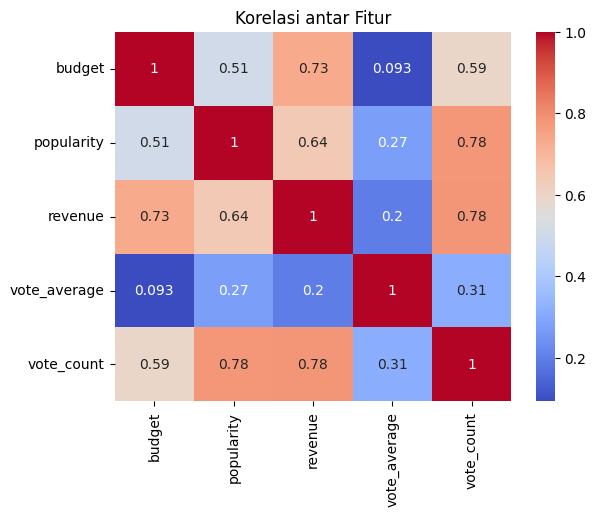

In [17]:
correlation = num_cols.corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Korelasi antar Fitur')
plt.show()

### 2.2 Univariate Analysis

In [18]:
# Simpan fitur sesuai tipe data 
num_cols = movie.select_dtypes(include=['int64', 'float64'])
cat_cols = movie.select_dtypes(include=['category', 'object'])

# Tampilkan fitur 
print('\nFitur numerik:', num_cols.columns.tolist())
print('Total fitur numerik:', num_cols.shape[1])
print('\nFitur kategori:', cat_cols.columns.tolist())
print('Total fitur kategori:', cat_cols.shape[1])


Fitur numerik: ['budget', 'popularity', 'revenue', 'vote_average', 'vote_count']
Total fitur numerik: 5

Fitur kategori: ['title', 'genres', 'production_companies']
Total fitur kategori: 3


/tmp/ipykernel_70953/2591630808.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = movie.select_dtypes(include=['category', 'object'])


/tmp/ipykernel_70953/2258872532.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=cat_cols, x='genres', palette='viridis')


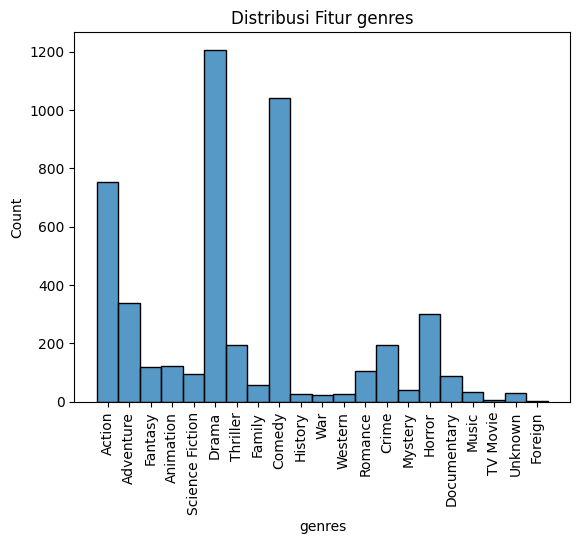

In [19]:
sns.histplot(data=cat_cols, x='genres', palette='viridis')
plt.xticks(rotation=90)
plt.title('Distribusi Fitur genres')
plt.show()

/tmp/ipykernel_70953/589541635.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10_data, y='genre_name', x='count', palette='viridis')


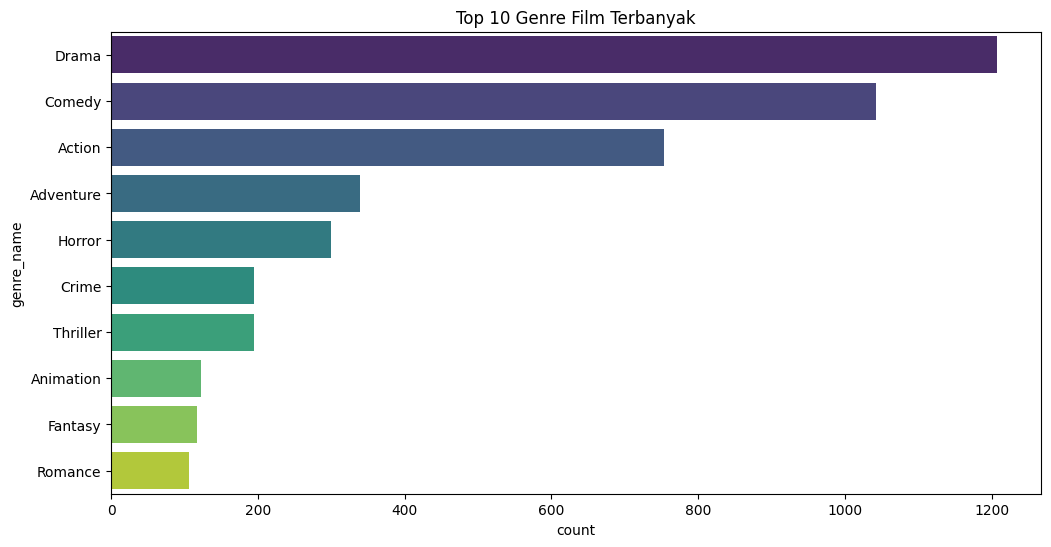

In [20]:
# Menyiapkan data
top_10_data = movie['genres'].value_counts().head(10).reset_index()
top_10_data.columns = ['genre_name', 'count']

plt.figure(figsize=(12, 6))
# Membuat barplot
ax = sns.barplot(data=top_10_data, y='genre_name', x='count', palette='viridis')
plt.title('Top 10 Genre Film Terbanyak')
plt.show()

/tmp/ipykernel_70953/270280620.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10_data, y='genre_name', x='count', palette='viridis')


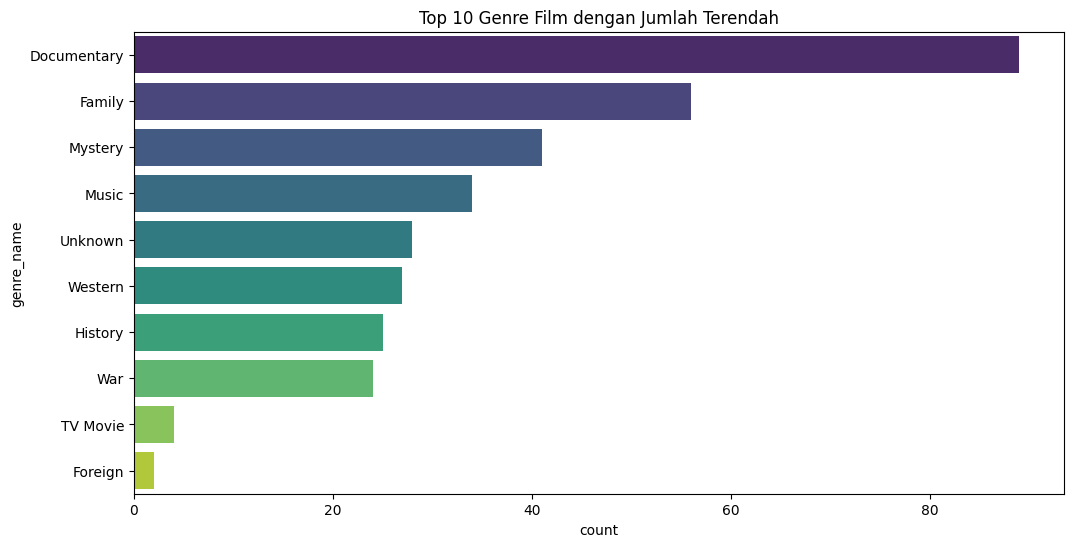

In [21]:
# Menyiapkan data
top_10_data = movie['genres'].value_counts().tail(10).reset_index()
top_10_data.columns = ['genre_name', 'count']

plt.figure(figsize=(12, 6))
# Membuat barplot
ax = sns.barplot(data=top_10_data, y='genre_name', x='count', palette='viridis')
plt.title('Top 10 Genre Film dengan Jumlah Terendah')
plt.show()

## 3. Data Preprocessing 

## 4. Model 

In [22]:
movie.head()

,title,budget,genres,popularity,production_companies,revenue,vote_average,vote_count
0,Avatar,237000000,Action,150.437577,Ingenious Film Partners,2787965087,7.2,11800
1,Pirates of the Caribbean: At World's End,300000000,Adventure,139.082615,Walt Disney Pictures,961000000,6.9,4500
2,Spectre,245000000,Action,107.376788,Columbia Pictures,880674609,6.3,4466
3,The Dark Knight Rises,250000000,Action,112.312950,Legendary Pictures,1084939099,7.6,9106
4,John Carter,260000000,Action,43.926995,Walt Disney Pictures,284139100,6.1,2124


## 5. Evaluasi

## 6. Visualisasi 

## 7. Kesimpulan